#### **Housing Price Prediction using Gradient Boosting Regressor** 

In [1]:
# Step 2 : Importing Required Libraries 
import pandas as pd               # for data handling (Dataframe)
import numpy as np                # for numerical opertions 
import matplotlib.pyplot as plt   # for plotting graphs 
import seaborn as sns             # for advanced visualizations 

# sklearn modules for ML workflow 
from sklearn.model_selection import train_test_split      # splitting data 
from sklearn.compose import ColumnTransformer             # handling different column types 
from sklearn.pipeline import Pipeline                     # combining preprocessing + model
from sklearn.preprocessing import OneHotEncoder           # converting categorical to numeric 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score  # for Evaluation
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
# Step 3 : Load the dataset 

df = pd.read_csv("housing_prices_dataset.csv")  # reading CSV file into Dataframe 

print("First 5 rows of dataset : ")  # quick look at data 
print(df.head())                     # show first 5 rows 

First 5 rows of dataset : 
   Square_Feet  Bedrooms  Bathrooms  Age_of_House  Floor_Number  Near_School  \
0         3674         2          3            11            20            0   
1         1360         2          2             6            11            0   
2         1794         3          4            28            11            0   
3         1630         2          3            10            11            1   
4         1595         1          2             0             2            1   

   Parking_Available    Location       Price  
0                  1      Nashik  24123535.0  
1                  1      Nashik  15109899.0  
2                  0  Aurangabad  18386187.0  
3                  1      Mumbai  27895122.0  
4                  0      Mumbai  29657447.0  


In [3]:
 # Step 4 : Basic data understanding 
 
print("\nDataset Shape : " , df.shape)      # (rows , columns )

print("\nColumn Names : ")
print(df.columns.tolist())                  # list of all columns 

print("\nDataset Info : ")
df.info()                                   # data types + null values 

print("\nMissing Values : ")
print(df.isnull().sum())                    # Check nulls column - wise  


Dataset Shape :  (600, 9)

Column Names : 
['Square_Feet', 'Bedrooms', 'Bathrooms', 'Age_of_House', 'Floor_Number', 'Near_School', 'Parking_Available', 'Location', 'Price']

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Square_Feet        600 non-null    int64  
 1   Bedrooms           600 non-null    int64  
 2   Bathrooms          600 non-null    int64  
 3   Age_of_House       600 non-null    int64  
 4   Floor_Number       600 non-null    int64  
 5   Near_School        600 non-null    int64  
 6   Parking_Available  600 non-null    int64  
 7   Location           600 non-null    object 
 8   Price              600 non-null    float64
dtypes: float64(1), int64(7), object(1)
memory usage: 42.3+ KB

Missing Values : 
Square_Feet          0
Bedrooms             0
Bathrooms            0
Age_of_House         0
Flo

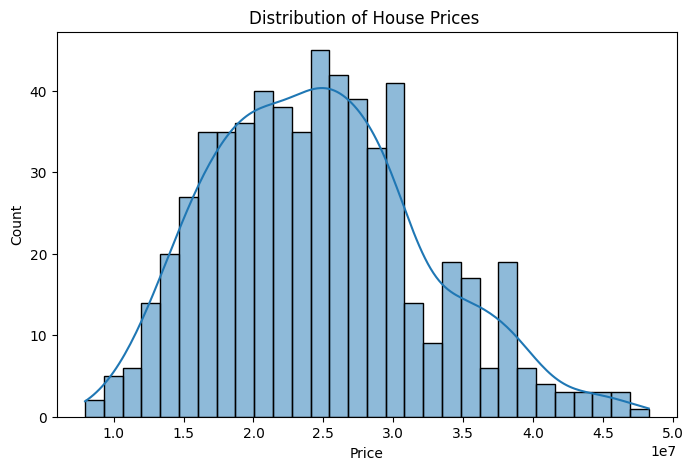

In [4]:
# Visualization 1 : Price distribution 
plt.figure(figsize= (8,5))                          # set plot size 
sns.histplot(df["Price"] , bins= 30 , kde= True)    # histogram + density curve 
plt.title("Distribution of House Prices ")          # plot title
plt.xlabel("Price")                                 # x-axis label
plt.ylabel("Count")                                 # y-axis label
plt.savefig("images/Distribution of House Prices.png") # save histplot 
plt.show()                                             # display plot 

# Insight : 
# -  Most houses are concentrated in the mid-price range (around 2M–3M), 
# -  while a few properties fall in the higher price range (3.5M–5M). 
# -  The distribution is slightly right-skewed, indicating the presence of premium properties that extend the upper tail.”

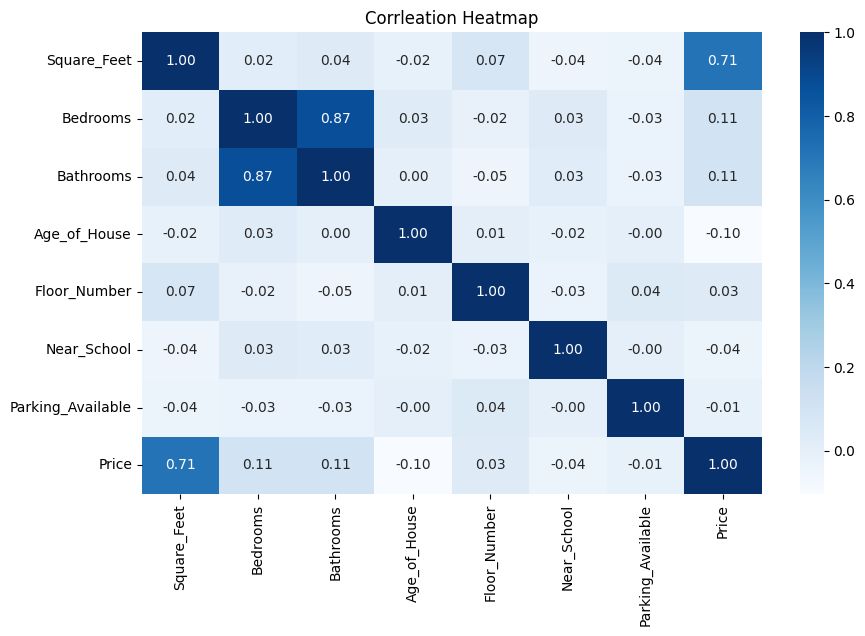

In [5]:
# Visualization 2 : Correlation Heatmap 
plt.figure(figsize=(10,6))     # bigger plot for clarity
sns.heatmap(df.corr(numeric_only=True),   # Correlation matrix 
            annot= True,                  # show values 
            cmap= "Blues",                # color theme
            fmt= ".2f")                   # format numbers 
plt.title("Corrleation Heatmap")
plt.savefig("images/Correlation Heatmap.png")
plt.show()

# Insight : 
# - From the correlation heatmap, square footage shows the strongest positive relationship with price (0.71),
# - making it the most important feature.
# - Bedrooms and bathrooms are highly correlated with each other (0.87), indicating multicollinearity.
# - However, their direct impact on price is relatively weak (~0.11), suggesting that overall size matters more than room count.
# - Age of the house has a slight negative impact on price, while other features show minimal influence.”

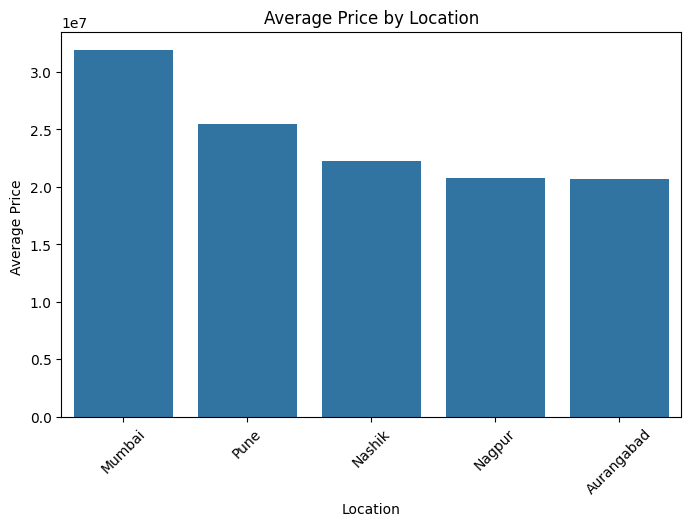

In [6]:
# Visualization 3 : Avg Price by Location 
avg_price_location = df.groupby("Location")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_location.index , y=avg_price_location.values)
plt.title("Average Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price ")
plt.xticks(rotation = 45)
plt.savefig("images/Average Price by Location")
plt.show()

# Insight : 
# - The average house price varies significantly by location, with Mumbai being the most expensive, followed by Pune.
# - Nashik represents a mid-range market, while Nagpur and Aurangabad are more affordable.
# - This clearly shows that location plays a major role in determining housing prices.

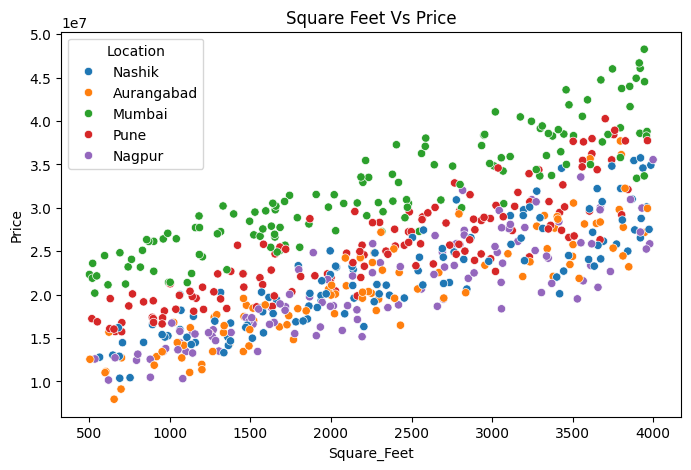

In [7]:
# Visualization 4 : Square Feet Vs Price 
plt.figure(figsize=(8,5))
sns.scatterplot(data=df , x = "Square_Feet" , y = "Price" , hue="Location")
plt.title("Square Feet Vs Price")
plt.xlabel("Square_Feet")
plt.ylabel("Price")
plt.savefig("images/Square Feet Vs Price ")
plt.show()

# Insight : 
# - The scatter plot shows a strong positive relationship between square footage and price, with a clear upward trend.
# - However, price variation across locations indicates that factors like location also play a significant role.
# - For the same property size, cities like Mumbai have higher prices compared to others.

In [8]:
# Step 5 : Define Features and Target

X = df.drop("Price" , axis=1)  # independent variables (inputs)
y = df["Price"]                # dependent variable (target)

In [9]:
# Step 6 : Separate column types 
categorical_features = ['Location'] # non- numeric column

numerical_features = [
    "Square_Feet",
    "Bedrooms",
    "Bathrooms",
    "Age_of_House",
    "Floor_Number",
    "Near_School",
    "Parking_Available"
]

In [10]:
# Step 7 : Preprocessing : 

preprocessor = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown="ignore") , categorical_features),  # encode location
        ("num" , "passthrough" , numerical_features)  # keep numeric columns as-is
    ]
)

In [11]:
# Step 8 : Build Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

num_cols = ['Square_Feet', 'Bedrooms', 'Bathrooms', 'Age_of_House', 'Floor_Number']
cat_cols = ['Near_School', 'Parking_Available', 'Location']

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

In [12]:
# Step 9 : Train- Test Split 
X_train , X_test , y_train , y_test = train_test_split(
    X,y,
    test_size=0.2,    # 20% for testing 
    random_state=42
)
print("\nTrain shape : ", X_train.shape)
print("\nTest shape : ", X_test.shape)


Train shape :  (480, 8)

Test shape :  (120, 8)


In [13]:
# Step 10 : Train Model 
model.fit(X_train , y_train)  # model learns patterns


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Square_Feet', 'Bedrooms',
                                                   'Bathrooms', 'Age_of_House',
                                                   'Floor_Number']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Near_School',
                                                   'Parking_Available',
                                                   'Location'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=200,
                                           random_state=42))])

In [14]:
# Step 11 : Predictions 
y_pred = model.predict(X_test)  # predict on unseen data 

In [15]:
# Step 12 : Evaluation : 
mae = mean_absolute_error(y_test , y_pred)  # average error
mse = mean_squared_error(y_test , y_pred) # squared error 
rmse = np.sqrt(mse)                         # root error
r2 = r2_score(y_test , y_pred)              # goodness of fit 

print("\nModel Performance : ")
print("MAE : " , round(mae , 2))
print("MSE : " , round(mse , 2))
print("RMSE : " , round(rmse , 2))
print("R2 Score : " , round(r2 , 2))


Model Performance : 
MAE :  2573498.29
MSE :  10347173326956.14
RMSE :  3216702.24
R2 Score :  0.81


In [16]:
# Step 13 : Actual Vs Predicted Table 

results = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted": y_pred
})
print("\nActual VS Predicted : ")
print(results.head(10))



Actual VS Predicted : 
       Actual     Predicted
0  10484751.0  1.197734e+07
1  26735036.0  2.892856e+07
2  28216786.0  2.646680e+07
3  34403297.0  3.417033e+07
4  19755748.0  2.281525e+07
5  33414375.0  3.796840e+07
6  25110743.0  2.197013e+07
7  16800233.0  1.601274e+07
8  25694283.0  2.486364e+07
9  10436295.0  1.295947e+07


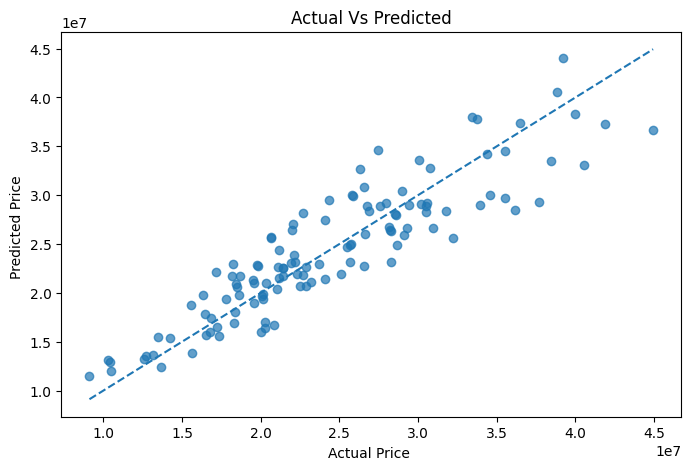

In [ ]:
# Visualization 5 : Actual Vs Predicted 
plt.figure(figsize=(8,5))
plt.scatter(y_test , y_pred , alpha=0.7)
plt.xlabel("Actual Price ")
plt.ylabel("Predicted Price ")
plt.title("Actual Vs Predicted")
# ideal prediction line 
plt.plot([y_test.min() , y_test.max()],
         [y_test.min() , y_test.max()],
         linestyle = "--")
plt.savefig("images/Actual Vs Predicted.png")
plt.show()

# Insight : 
# - The Actual vs Predicted plot shows that most predictions lie close to the ideal diagonal line, indicating good model accuracy.
# - The strong alignment suggests the model has captured the relationship effectively,
# - although some deviations exist, especially for high-priced properties,
# - which are generally harder to predict.

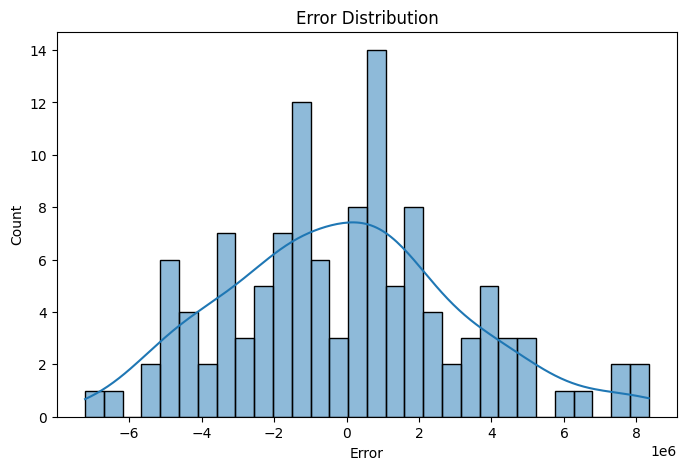

In [ ]:
# Visualization 6 : Error Distribution 

errors = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(errors , bins = 30 , kde=True)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.savefig("images/Error Distribution.png")
plt.show()

# Insight : 
# - The error distribution is centered around zero and follows a near-normal shape,
# - indicating that the model predictions are unbiased and errors are randomly distributed.
# - Most errors are small, showing good accuracy, although a few large deviations exist for complex cases.

In [20]:
# exact same feature lists used in preprocessor
numerical_features = ['Square_Feet', 'Bedrooms', 'Bathrooms', 'Age_of_House', 'Floor_Number']
cat_cols = ['Near_School', 'Parking_Available', 'Location']

encoded_cat = model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_features = numerical_features + list(encoded_cat)

importances = model.named_steps["regressor"].feature_importances_

feature_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df)

                Feature  Importance
0           Square_Feet    0.571154
7       Location_Mumbai    0.291433
10        Location_Pune    0.049478
3          Age_of_House    0.031928
2             Bathrooms    0.017334
1              Bedrooms    0.013707
4          Floor_Number    0.013225
8       Location_Nagpur    0.004975
6   Parking_Available_1    0.004196
5         Near_School_1    0.001488
9       Location_Nashik    0.001082


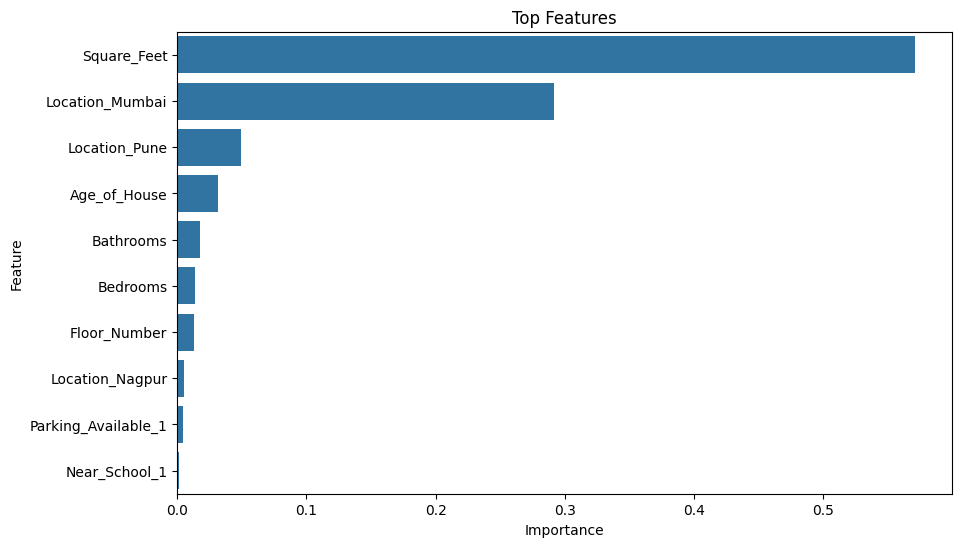

In [ ]:
# Visualization 7 : Feature Importance Plot 
plt.figure(figsize=(10,6))
sns.barplot(data = feature_df.head(10) , x="Importance" , y="Feature")
plt.title("Top Features")
plt.savefig("images/Top Features.png")
plt.show()

# insight : 
# - Feature importance shows that square footage is the most influential factor in predicting house prices,
#   followed by location, particularly Mumbai.
# - Other features like bedrooms, bathrooms, and amenities have minimal impact, 
#   indicating that overall size and location are the key drivers of price.


In [22]:
## Step 15: New Prediction


new_house = pd.DataFrame({
    "Square_Feet": [2200],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Age_of_House": [5],
    "Floor_Number": [7],
    "Near_School": [1],
    "Parking_Available": [1],
    "Location": ["Pune"]
})

pred_price = model.predict(new_house)

print("\nPredicted Price:", round(pred_price[0], 2))



Predicted Price: 25715334.47


In [ ]:
# Final Thought: 

# Gradient Boosting works really well for regression problems
# because it learns complex patterns step by step.

In [ ]:
### **Final Conclusion :**

# -In this project, I built a housing price prediction model using Gradient Boosting Regressor. 
# - Through exploratory data analysis, 
# - I identified that square footage and location are the most significant factors influencing house prices. 
# - The model demonstrated strong performance, 
# - with predictions closely aligning with actual values and errors being mostly small and unbiased. 
# - Feature importance further confirmed that size and location are the primary drivers of price. 
# - Finally, I validated the model by predicting the price of a new unseen house, showing its practical real-world usability.